In [11]:
!apt-get install -y python3-rdkit
!pip install rdkit

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-rdkit is already the newest version (202109.2-1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [12]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [13]:
from google.colab import files

uploaded = files.upload()

Saving drug_taste_dataset.csv to drug_taste_dataset (1).csv


In [14]:
df = pd.read_csv("drug_taste_dataset.csv")

print(df.head())

print(df.shape)

                          SMILES   Taste
0          CC(=O)NC1=CC=C(O)C=C1  Bitter
1       CC(=O)OC1=CC=CC=C1C(=O)O  Bitter
2  CC(C)CC1=CC=C(C=C1)C(C)C(=O)O  Bitter
3              CN(C)C(=N)NC(=N)N  Bitter
4   CN1C=NC2=C1C(=O)N(C(=O)N2C)C  Bitter
(31, 2)


In [15]:
df = df.dropna()

print(df.shape)

(30, 2)


In [16]:
def smiles_to_fingerprint(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )

    return np.array(fp)

In [17]:
X = []
y = []

for _, row in df.iterrows():

    fp = smiles_to_fingerprint(row["SMILES"])

    if fp is not None:

        X.append(fp)

        y.append(row["Taste"])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(29, 2048)
(29,)


[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] SMILES Parse Error: unclosed ring for input: 'CN1CCC23C4C1CC5=C2C=CC(O)=C5O3'
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WARNING: please use MorganGenerator
[11:43:31] DEPRECATION WAR

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
model = MLPClassifier(

    hidden_layer_sizes=(64,32),

    activation="relu",

    solver="adam",

    max_iter=1000,

    random_state=42

)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy*100,2),"%")
print("Precision :", round(precision*100,2),"%")
print("Recall :", round(recall*100,2),"%")
print("F1 Score :", round(f1*100,2),"%")

print()

print(classification_report(y_test,y_pred))

Accuracy : 83.33 %
Precision : 87.5 %
Recall : 83.33 %
F1 Score : 82.86 %

              precision    recall  f1-score   support

      Bitter       1.00      0.67      0.80         3
       Sweet       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



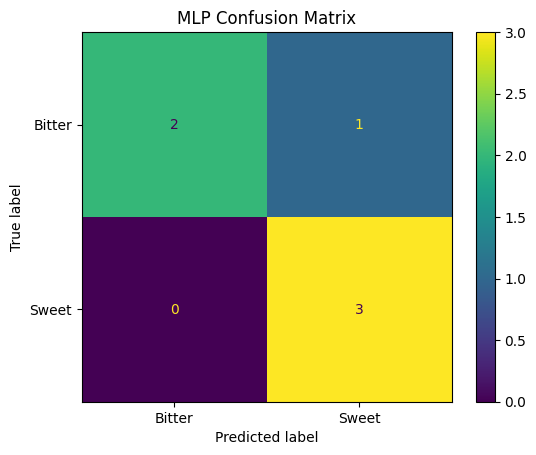

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("MLP Confusion Matrix")

plt.show()

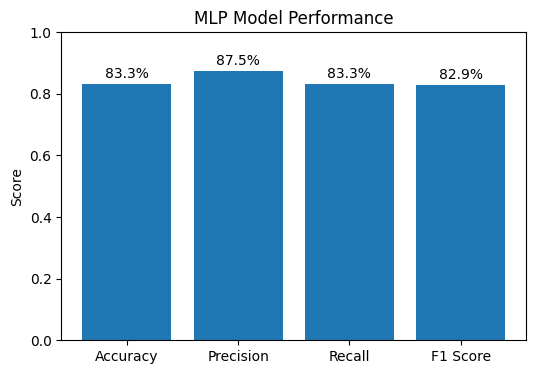

In [23]:
metrics = ["Accuracy","Precision","Recall","F1 Score"]

scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))

bars = plt.bar(metrics, scores)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("MLP Model Performance")

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        score+0.02,
        f"{score*100:.1f}%",
        ha="center"
    )

plt.show()

In [24]:
joblib.dump(
    model,
    "taste_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
from google.colab import files

files.download("taste_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>